# 回测结果分析面板

这份 notebook 用于**结果分析**，默认读取导出的回测结果文件，重点看：

- 绩效摘要  
- 资产相关性矩阵
- 历史风险贡献度
- 净值与回撤  
- 年度收益  
- 月度收益热力图  
- 调仓次数与换手  
- 各资产平均权重与最后权重


In [1]:

from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("data/exports")

nav_df = pd.read_csv(EXPORT_DIR / "nav.csv", index_col=0, parse_dates=True)
weights_df = pd.read_csv(EXPORT_DIR / "weights.csv", index_col=0, parse_dates=True)
positions_df = pd.read_csv(EXPORT_DIR / "positions.csv", index_col=0, parse_dates=True)
target_weights_df = pd.read_csv(EXPORT_DIR / "target_weights.csv", index_col=0, parse_dates=True)
trades_df = pd.read_csv(EXPORT_DIR / "trades.csv")
rebalance_log_df = pd.read_csv(EXPORT_DIR / "rebalance_log.csv")
summary = pd.read_csv(EXPORT_DIR / "summary.csv", index_col=0)

asset_corr_matrix = pd.read_csv(
    EXPORT_DIR / "asset_corr_matrix.csv", 
    index_col=0
    )
risk_contribution_df = pd.read_csv(
    EXPORT_DIR / "risk_contribution_df.csv", 
    index_col=0, 
    parse_dates=True  # 核心：让 Pandas 把 Index 重新识别为时间格式
    )


plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("files loaded")
display(summary)


files loaded


,0
total_return,0.234156
annual_return,0.070522
excess_return,0.070522
annual_volatility,0.039171
sharpe_ratio,1.757246
max_drawdown,-0.029989
calmar_ratio,-2.351592
avg_asset_correlation,0.135079


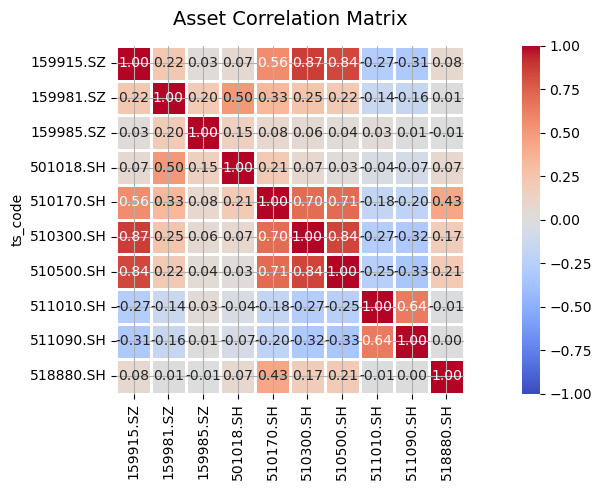

In [2]:
# ========= 资产相关性矩阵 =========
# plt.figure(figsize=(8, 6))
# 使用 coolwarm 色系：红代表高度正相关，蓝代表负相关
sns.heatmap(
    asset_corr_matrix, 
    annot=True,        # 在格子里显示具体数值
    cmap='coolwarm',   # 冷暖色调
    vmin=-1, vmax=1,   # 相关性系数的理论极值
    center=0,          # 0 设为中间色（通常是白色或浅灰色）
    fmt='.2f',         # 保留两位小数
    linewidths=1,      # 格子之间的间距线
    square=True        # 保持格子是正方形
)

plt.title('Asset Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

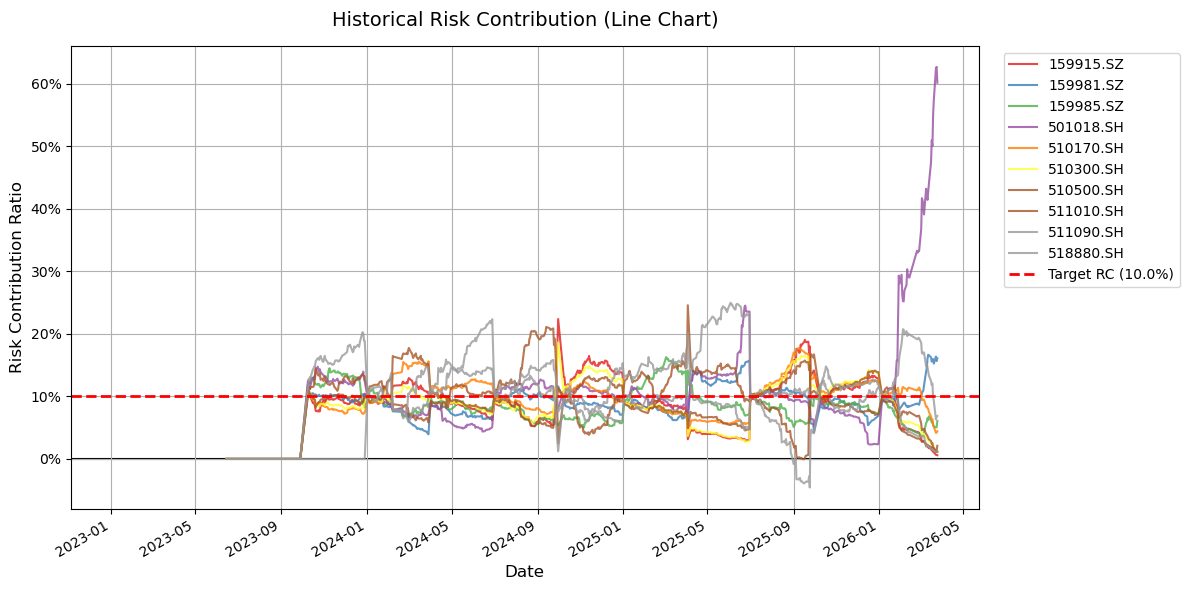

In [5]:
import matplotlib.ticker as ticker
# 创建画布
fig, ax = plt.subplots(figsize=(12, 6))

# 直接画折线图，而不是面积图
risk_contribution_df.plot.line(
    ax=ax, 
    linewidth=1.5, 
    alpha=0.8,
    colormap='Set1' # 使用对比度高的色系
)

# 1. 画一条 0 轴的黑色实线，用来捕捉负风险贡献
plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=1)

# 2. 画一条“目标风险平价线”的红色虚线
num_assets = len(risk_contribution_df.columns)
target_ratio = 1.0 / num_assets
plt.axhline(target_ratio, color='red', linewidth=2, linestyle='--', 
            label=f'Target RC ({target_ratio:.1%})', zorder=2)

plt.title('Historical Risk Contribution (Line Chart)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Risk Contribution Ratio', fontsize=12)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

# 调整图例
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

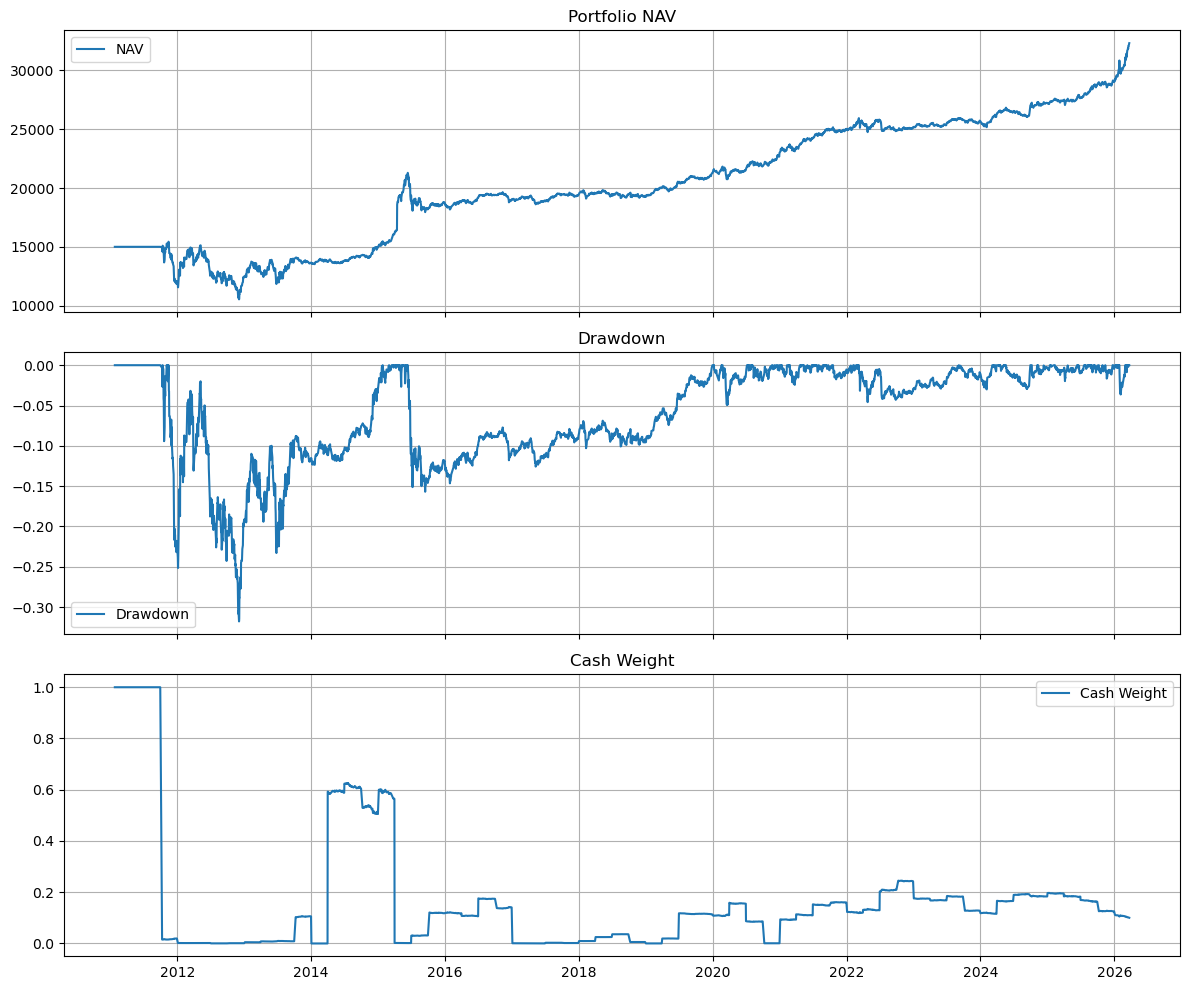

平均现金占比： 0.1643
最大现金占比： 1.0
最近现金占比： 0.1004


In [ ]:
# ========= 基础序列 =========
nav = nav_df["nav"].copy()
cash_weight = nav_df["cash"] / nav_df["nav"]
daily_ret = nav.pct_change().fillna(0.0)
drawdown = nav / nav.cummax() - 1.0

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. 净值
axes[0].plot(nav.index, nav, label="NAV")
axes[0].set_title("Portfolio NAV")
axes[0].legend()

# 2. 回撤
axes[1].plot(drawdown.index, drawdown, label="Drawdown")
axes[1].set_title("Drawdown")
axes[1].legend()

# 3. 现金占比
axes[2].plot(cash_weight.index, cash_weight, label="Cash Weight")
axes[2].set_title("Cash Weight")
axes[2].legend()

plt.tight_layout()
plt.show()

print("平均现金占比：", round(cash_weight.mean(), 4))
print("最大现金占比：", round(cash_weight.max(), 4))
print("最近现金占比：", round(cash_weight.iloc[-1], 4))

C:\Users\12178\AppData\Local\Temp\ipykernel_18784\881751147.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  year_end_nav = nav.resample("Y").last()


,annual_return
trade_date,
2011,NaN
2012,0.034145
2013,0.094336
2014,0.095845
2015,0.249756
2016,0.017273
2017,0.020026
2018,-0.003691
2019,0.102180


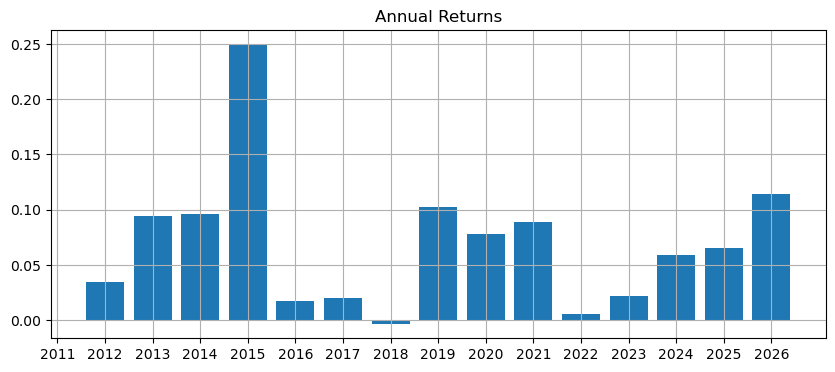

In [ ]:

# ========= 年度收益 =========
year_end_nav = nav.resample("Y").last()
annual_returns = year_end_nav.pct_change()
annual_returns.index = annual_returns.index.year

annual_returns_df = annual_returns.to_frame("annual_return")
display(annual_returns_df)

plt.figure(figsize=(10, 4))
plt.bar(annual_returns_df.index.astype(str), annual_returns_df["annual_return"])
plt.title("Annual Returns")
plt.show()


C:\Users\12178\AppData\Local\Temp\ipykernel_18784\561823234.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav.resample("M").last()


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2011,nan%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.94%,-6.44%,-13.17%
2012,12.39%,7.56%,-8.05%,6.97%,0.56%,-11.53%,-6.42%,-0.35%,3.04%,-3.18%,-9.62%,16.28%
2013,6.17%,2.05%,-4.76%,-1.99%,9.19%,-13.12%,3.40%,6.27%,6.32%,-1.09%,0.13%,-1.42%
2014,0.32%,1.26%,-1.17%,-0.40%,-0.12%,1.23%,1.55%,0.40%,1.35%,-0.59%,1.92%,3.53%
2015,1.87%,1.34%,4.11%,20.62%,4.35%,-4.35%,-4.37%,-0.83%,-0.88%,2.22%,-0.93%,1.45%
2016,-2.62%,1.86%,1.64%,-0.04%,-0.44%,2.08%,0.88%,0.54%,-0.06%,0.48%,-0.80%,-1.69%
2017,-0.15%,1.39%,-0.67%,-0.54%,-1.57%,0.77%,1.69%,0.78%,0.61%,-0.23%,-0.26%,0.22%
2018,0.85%,-0.66%,0.66%,0.24%,-0.08%,-0.59%,0.50%,-1.11%,0.64%,-0.92%,-0.39%,0.54%
2019,0.64%,1.88%,0.81%,-0.51%,0.37%,2.42%,0.40%,1.83%,-0.28%,-0.39%,0.22%,2.45%


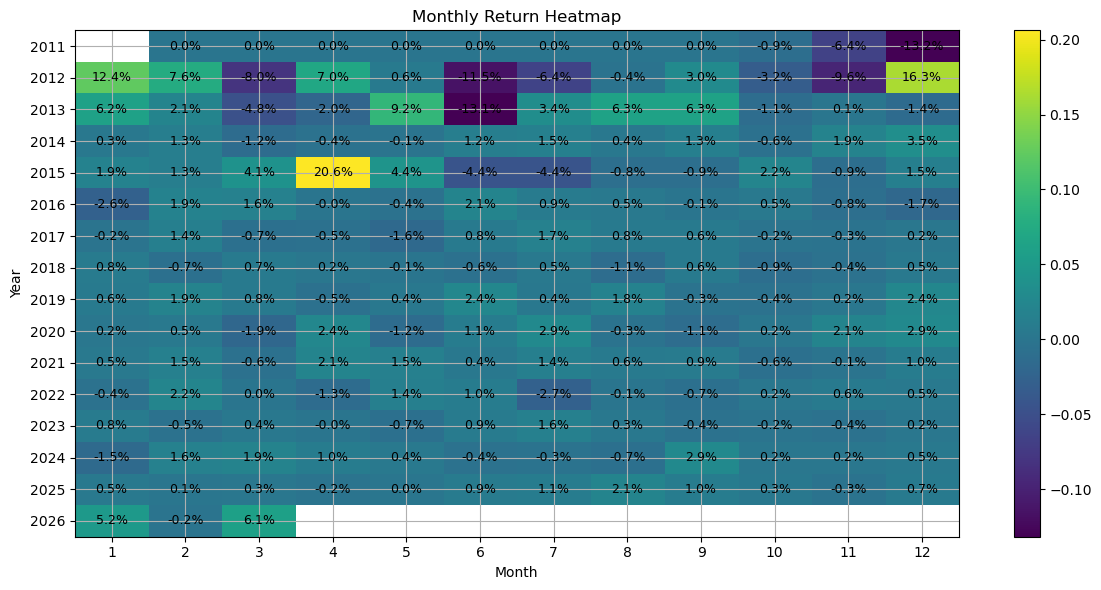

In [ ]:

# ========= 月度收益热力图（表格版） =========
month_end_nav = nav.resample("M").last()
monthly_returns = month_end_nav.pct_change()
monthly_df = monthly_returns.to_frame("monthly_return")
monthly_df["year"] = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month

heatmap_table = monthly_df.pivot(index="year", columns="month", values="monthly_return")
display(heatmap_table.style.format("{:.2%}"))
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_table.values, aspect="auto")

ax.set_xticks(range(len(heatmap_table.columns)))
ax.set_xticklabels(heatmap_table.columns)

ax.set_yticks(range(len(heatmap_table.index)))
ax.set_yticklabels(heatmap_table.index)

ax.set_title("Monthly Return Heatmap")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

for i in range(heatmap_table.shape[0]):
    for j in range(heatmap_table.shape[1]):
        val = heatmap_table.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:

# ========= 调仓统计 =========
if len(rebalance_log_df) > 0:
    rebalance_log_df["trade_date"] = pd.to_datetime(rebalance_log_df["trade_date"])
    rebalance_log_df["year"] = rebalance_log_df["trade_date"].dt.year

    print("调仓日志：")
    display(rebalance_log_df.tail(20))

    yearly_rebalance_count = rebalance_log_df.groupby("year").size().rename("rebalance_count")
    yearly_turnover = rebalance_log_df.groupby("year")["turnover"].sum().rename("turnover_sum")

    display(pd.concat([yearly_rebalance_count, yearly_turnover], axis=1))
else:
    print("没有调仓记录")


调仓日志：


,signal_date,trade_date,reason,drift_value,turnover,cash_after_trade,traded,trade_count,year
38,2021-03-31,2021-04-01,schedule,NaN,0.141505,2664.568725,1,15,2021
39,2021-06-30,2021-07-01,schedule,NaN,0.042767,3702.846325,1,16,2021
40,2021-09-30,2021-10-08,schedule,NaN,0.031120,3993.576188,1,17,2021
41,2021-12-31,2022-01-04,schedule,NaN,0.051039,3071.806963,1,17,2022
42,2022-03-31,2022-04-01,schedule,NaN,0.104832,3337.660300,1,16,2022
43,2022-06-30,2022-07-01,schedule,NaN,0.073003,5214.563700,1,16,2022
44,2022-09-30,2022-10-10,schedule,NaN,0.035931,6106.814275,1,16,2022
45,2022-12-30,2023-01-03,schedule,NaN,0.066880,4429.355950,1,17,2023
46,2023-03-31,2023-04-03,schedule,NaN,0.071435,4274.032400,1,13,2023
47,2023-06-30,2023-07-03,schedule,NaN,0.018204,4732.628638,1,16,2023


,rebalance_count,turnover_sum
year,,
2011,1,0.984453
2012,4,1.007051
2013,4,2.730296
2014,4,1.066506
2015,4,1.223602
2016,4,0.171437
2017,4,0.280508
2018,4,0.298553
2019,4,0.322717


In [ ]:

# ========= 交易统计 =========
if len(trades_df) > 0:
    trade_summary = trades_df.groupby(["ts_code", "side"])["trade_value"].agg(["count", "sum"])
    display(trade_summary)

    fee_summary = trades_df.groupby("side")["cost"].sum().rename("total_cost")
    display(fee_summary)
else:
    print("没有交易记录")


count         sum
ts_code   side                   
159915.SZ BUY     134   16610.750
          SELL     38   19483.150
159981.SZ BUY      47    5686.525
          SELL     12    4682.450
159985.SZ BUY      46    6519.600
          SELL     12    5515.000
501018.SH BUY      71    6946.050
          SELL     20    5550.850
510170.SH BUY     129   26367.425
          SELL     36   23076.225
510300.SH BUY      67   23170.375
          SELL     37   22851.550
510500.SH BUY      47   24991.475
          SELL     36   26607.250
511010.SH BUY      10  116083.975
          SELL      9  105471.100
518880.SH BUY      73   24608.675
          SELL     34   26235.950

side
BUY     125.492425
SELL    119.736762
Name: total_cost, dtype: float64

最后一期实际权重：


,last_weight
511010.SH,0.435517
501018.SH,0.126629
159985.SZ,0.076303
159981.SZ,0.069181
518880.SH,0.057541
510500.SH,0.047350
510300.SH,0.041573
510170.SH,0.025525
159915.SZ,0.020030
511090.SH,0.000000


样本期平均实际权重：


,avg_weight
511010.SH,0.416765
510170.SH,0.111121
518880.SH,0.094772
510300.SH,0.058811
159915.SZ,0.058670
510500.SH,0.038228
501018.SH,0.023122
159985.SZ,0.019562
159981.SZ,0.014696
511090.SH,0.000000


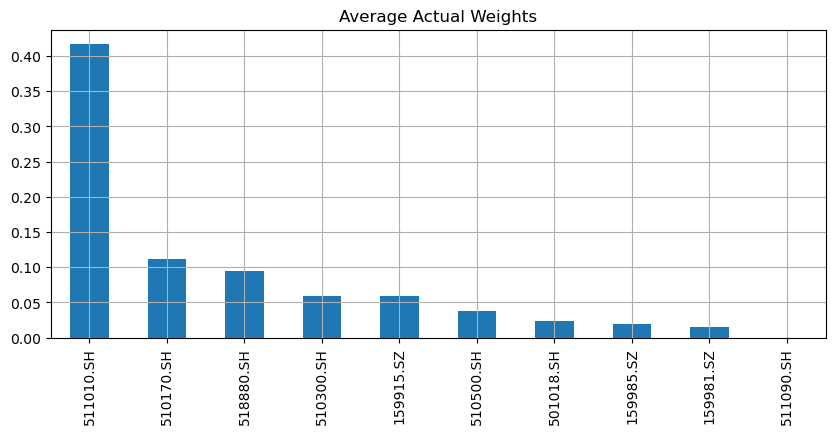

In [ ]:

# ========= 权重分析 =========
print("最后一期实际权重：")
display(weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "last_weight"}).sort_values("last_weight", ascending=False))

print("样本期平均实际权重：")
avg_weight = weights_df.mean().sort_values(ascending=False).to_frame("avg_weight")
display(avg_weight)

plt.figure(figsize=(10, 4))
avg_weight["avg_weight"].plot(kind="bar")
plt.title("Average Actual Weights")
plt.show()


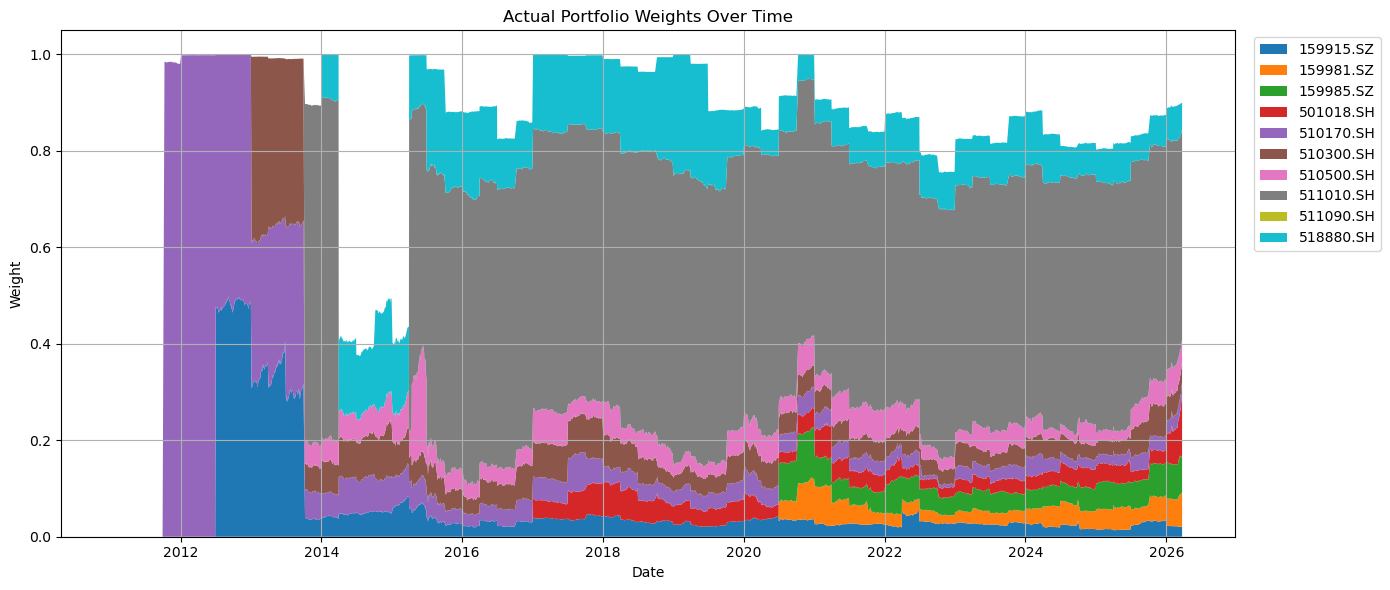

In [ ]:
# ========= 实际持有比例变化 =========
actual_weights_plot = weights_df.copy().fillna(0.0)

plt.figure(figsize=(14, 6))
plt.stackplot(
    actual_weights_plot.index,
    actual_weights_plot.T.values,
    labels=actual_weights_plot.columns
)
plt.title("Actual Portfolio Weights Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

In [ ]:

# ========= 最近持仓与目标权重对比 =========
if len(weights_df) > 0 and len(target_weights_df) > 0:
    last_actual = weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "actual_weight"})
    last_target = target_weights_df.tail(1).T.rename(columns={target_weights_df.index[-1]: "target_weight"})
    compare = last_actual.join(last_target, how="outer").fillna(0.0)
    compare["diff"] = compare["actual_weight"] - compare["target_weight"]
    display(compare.sort_values("target_weight", ascending=False))


,actual_weight,target_weight,diff
511010.SH,0.435517,0.538609,-0.103092
511090.SH,0.000000,0.212586,-0.212586
159985.SZ,0.076303,0.058139,0.018164
510300.SH,0.041573,0.044651,-0.003077
159915.SZ,0.020030,0.032828,-0.012798
510500.SH,0.047350,0.029317,0.018033
159981.SZ,0.069181,0.028353,0.040828
501018.SH,0.126629,0.019527,0.107102
518880.SH,0.057541,0.019015,0.038526
510170.SH,0.025525,0.016975,0.008550


In [ ]:

# ========= 核心结论快照 =========
snapshot = {
    "summary": summary,
    "last_nav": nav.iloc[-1],
    "max_drawdown": drawdown.min(),
    "last_positions": positions_df.tail(1).T if len(positions_df) > 0 else None,
    "last_weights": weights_df.tail(1).T if len(weights_df) > 0 else None,
    "rebalance_count": len(rebalance_log_df),
    "trade_count": len(trades_df),
}

snapshot["summary"]


,0
total_return,1.154743
annual_return,0.053990
annual_volatility,0.110224
sharpe_ratio,0.531516
max_drawdown,-0.317777
